In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

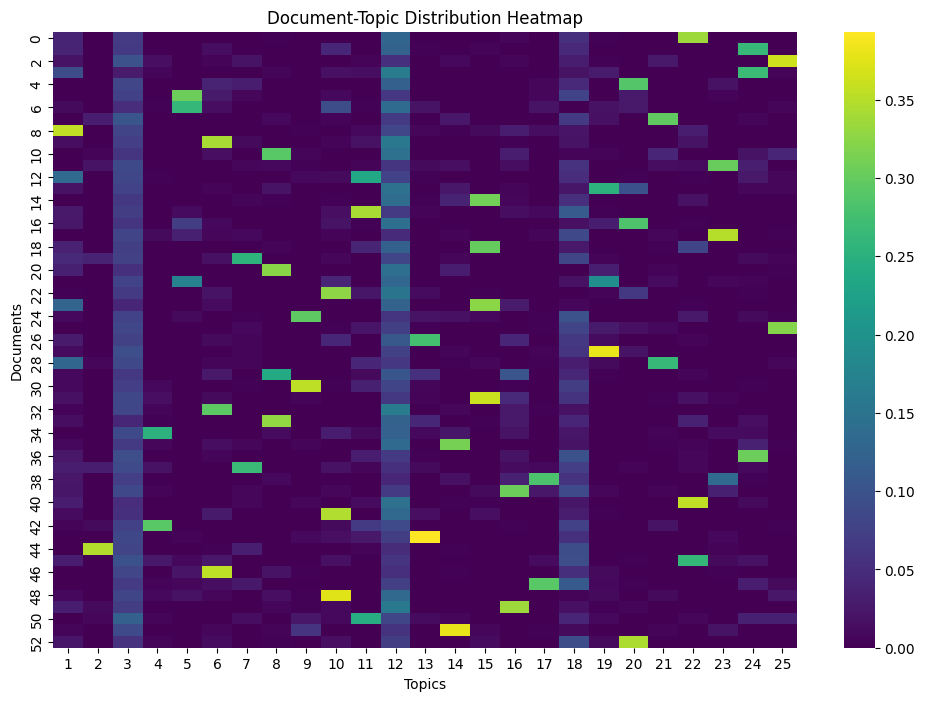

In [3]:
df = pd.read_csv("../data/topic_modeling/doctopics.csv", header=None)
# drop firts column
df = df.drop(columns=[0])

plt.figure(figsize=(12, 8))
sns.heatmap(df, cmap="viridis")

plt.title("Document-Topic Distribution Heatmap")
plt.xlabel("Topics")
plt.ylabel("Documents")
plt.show()

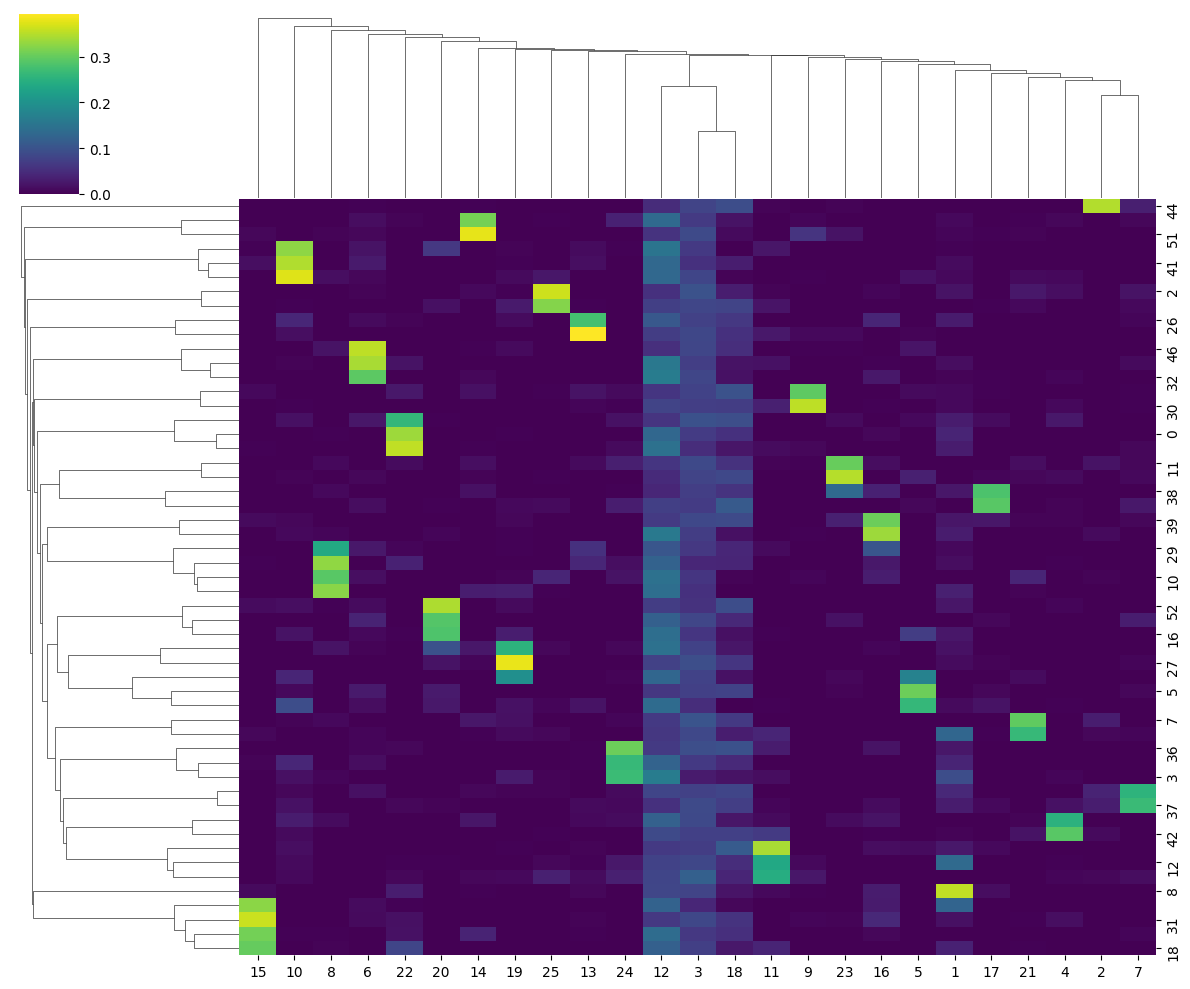

In [ ]:
# Clustering of ministries based on topics
# if each row = ministry
sns.clustermap(df, cmap="viridis", figsize=(12,10))

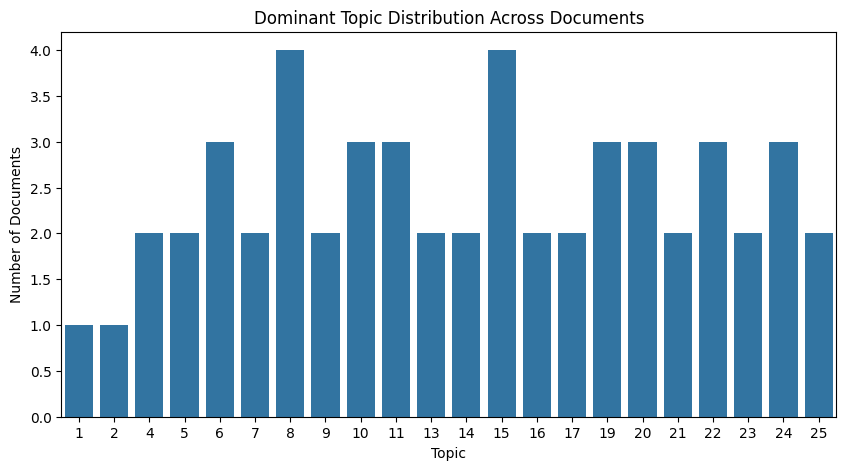

In [4]:
import numpy as np

dominant_topic = df.idxmax(axis=1)

plt.figure(figsize=(10,5))
sns.countplot(x=dominant_topic)

plt.title("Dominant Topic Distribution Across Documents")
plt.xlabel("Topic")
plt.ylabel("Number of Documents")
plt.show()

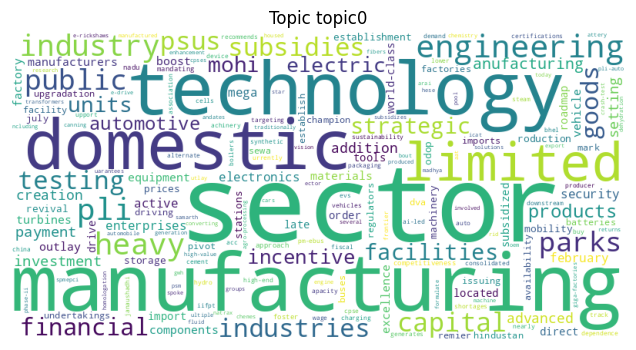

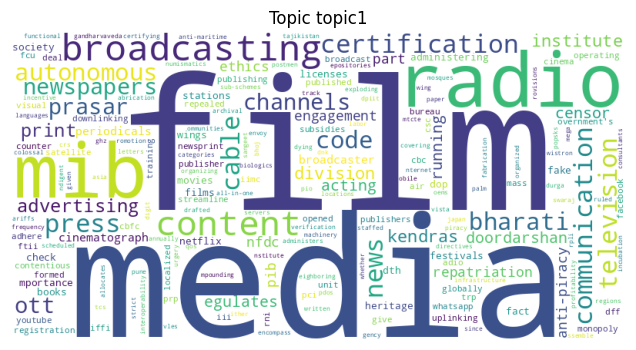

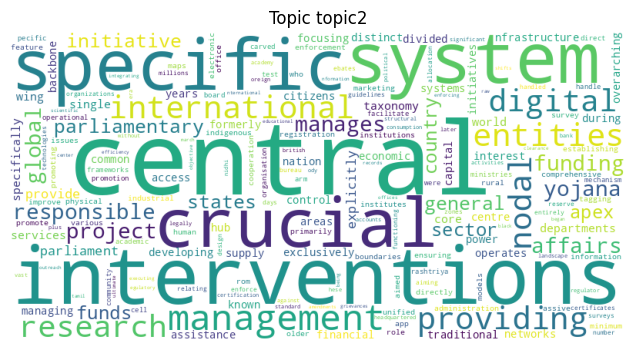

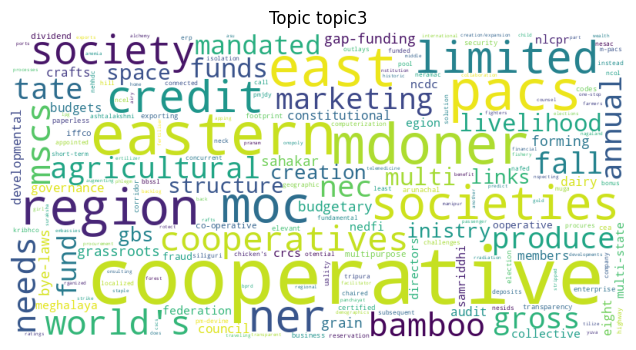

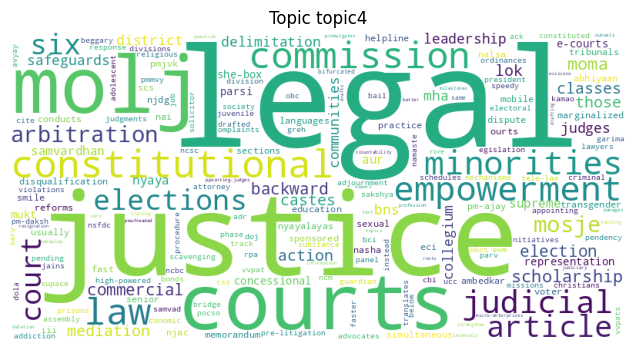

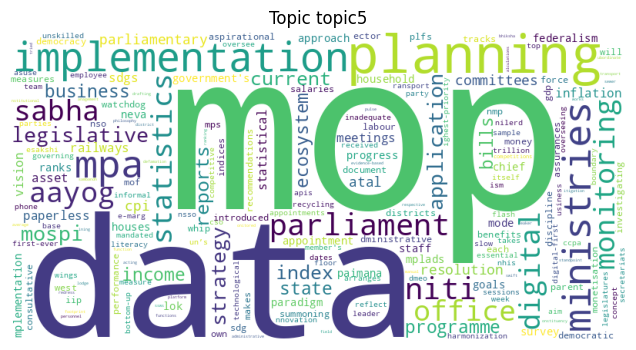

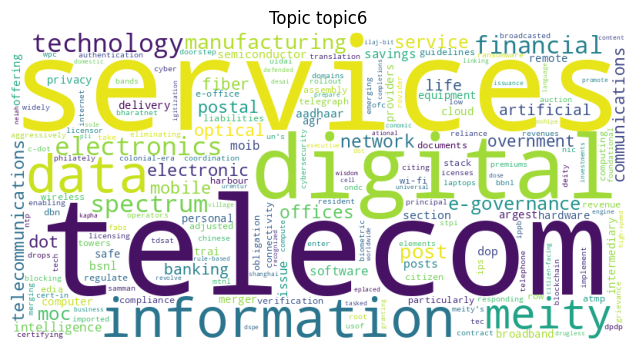

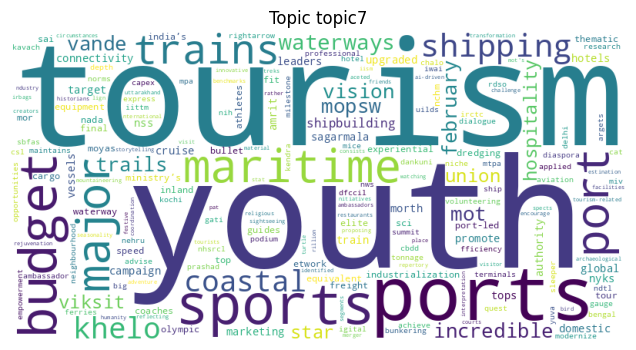

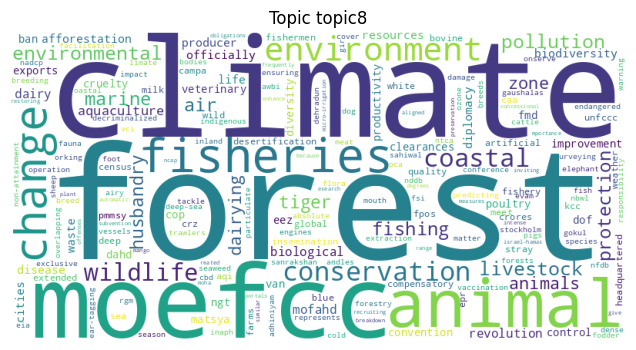

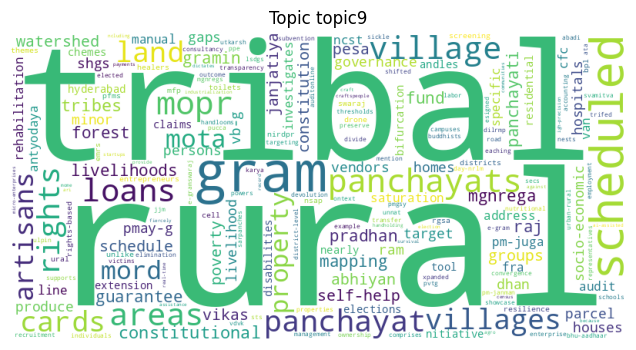

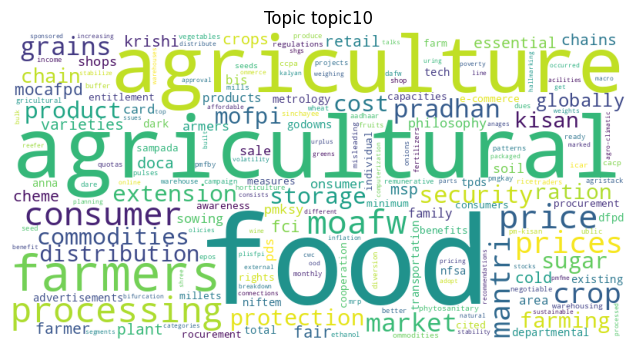

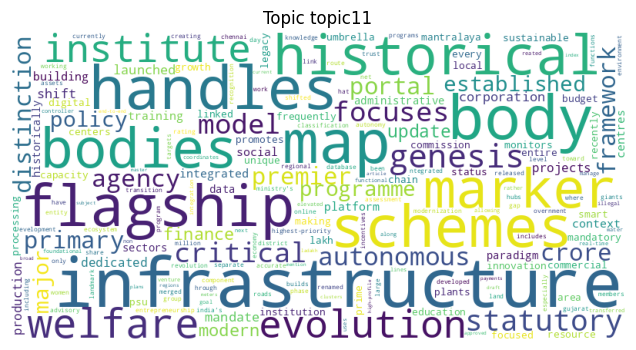

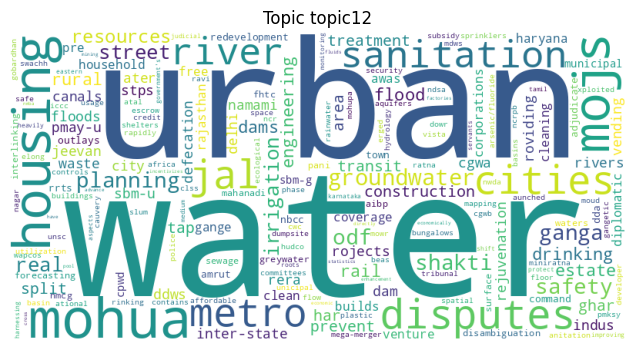

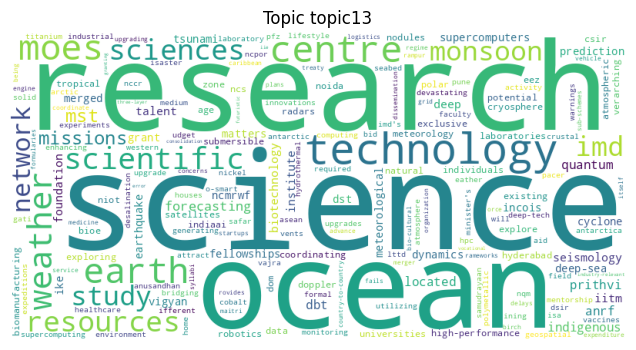

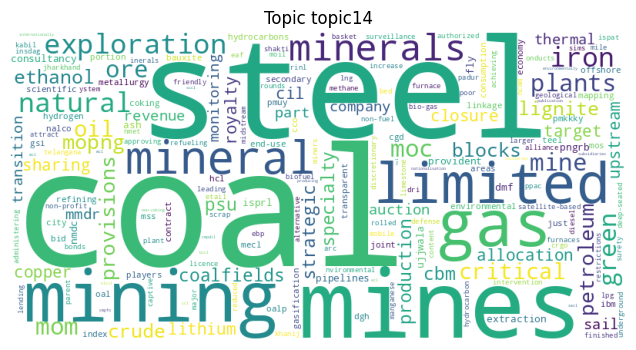

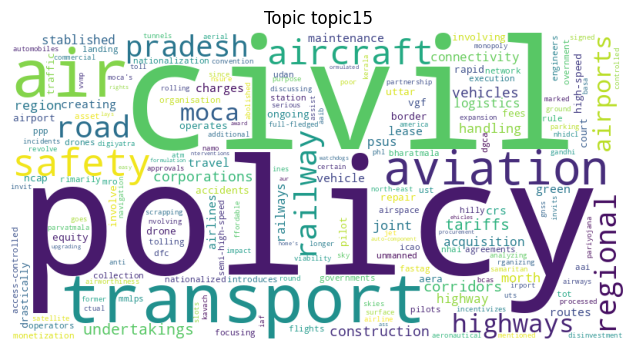

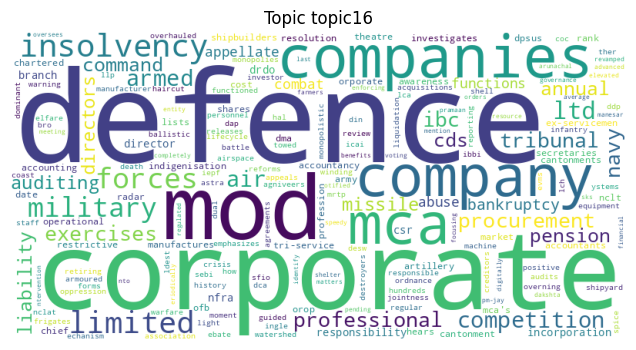

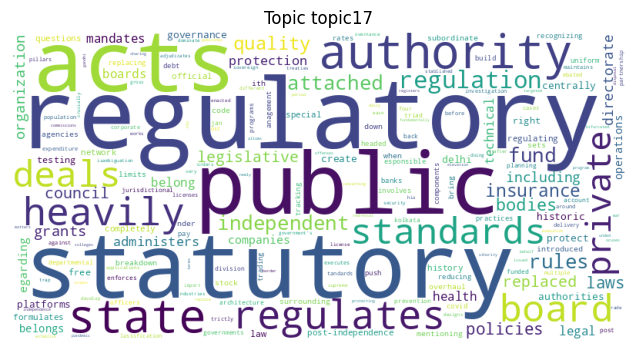

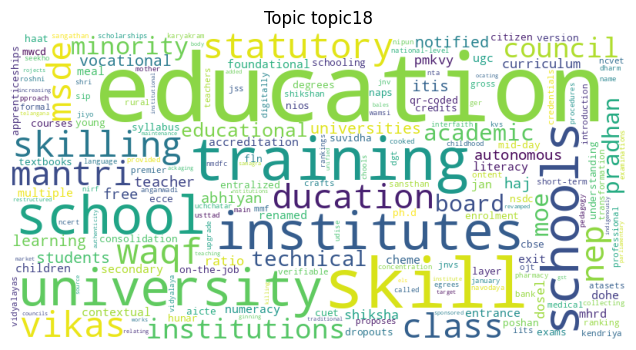

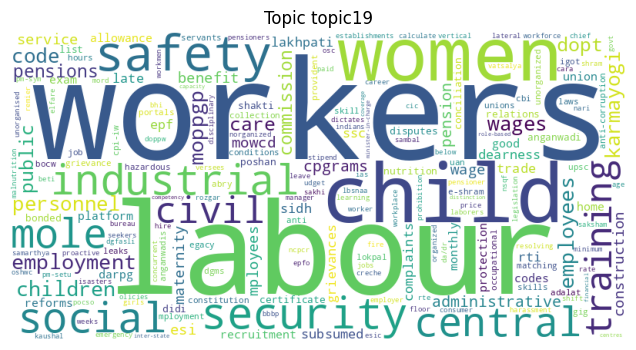

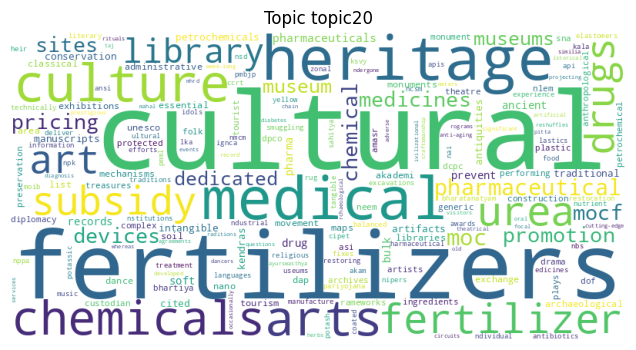

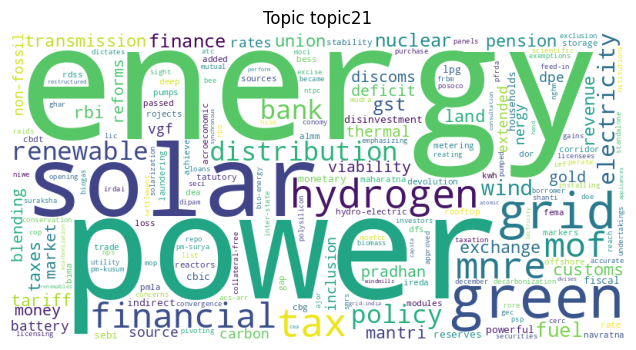

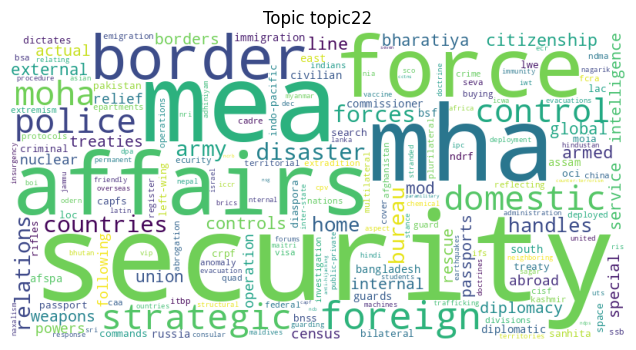

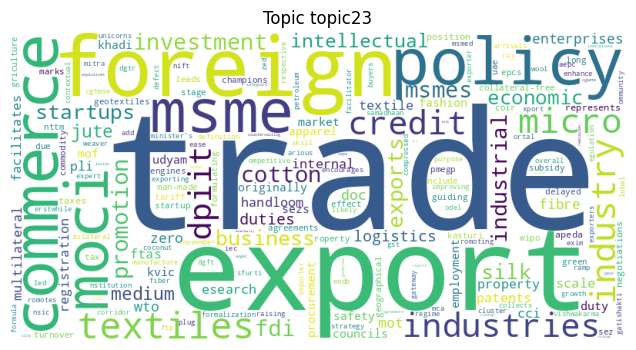

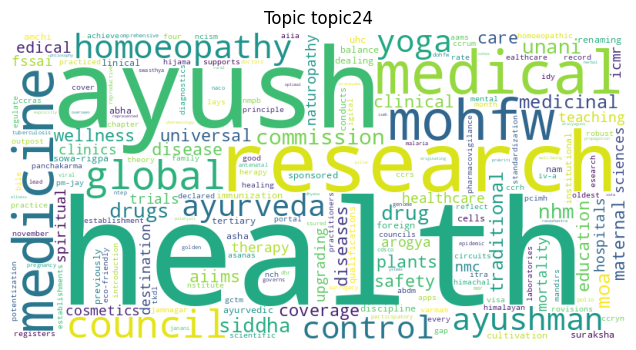

In [7]:
from wordcloud import WordCloud

topic_words = pd.read_csv("../data/topic_modeling/topicwords.csv")

for topic in topic_words.columns[1:]:
    word_freq = topic_words[["word", topic]]
    word_freq = word_freq.set_index("word")[topic].to_dict()

    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate_from_frequencies(word_freq)

    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Topic {topic}")
    plt.show()

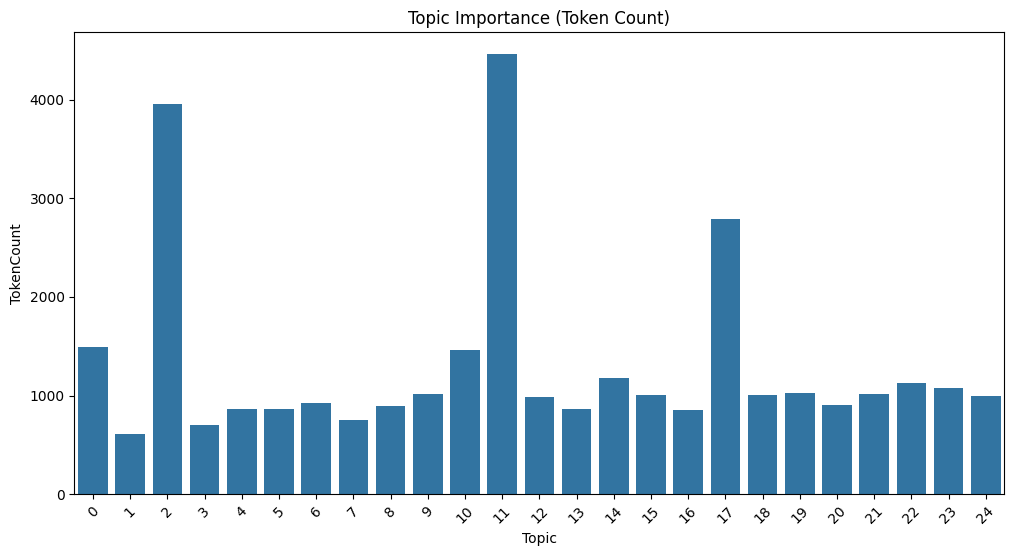

In [8]:
summary = pd.read_csv("../data/topic_modeling/keys.csv")

plt.figure(figsize=(12,6))
sns.barplot(x="Topic", y="TokenCount", data=summary)

plt.title("Topic Importance (Token Count)")
plt.xticks(rotation=45)
plt.show()

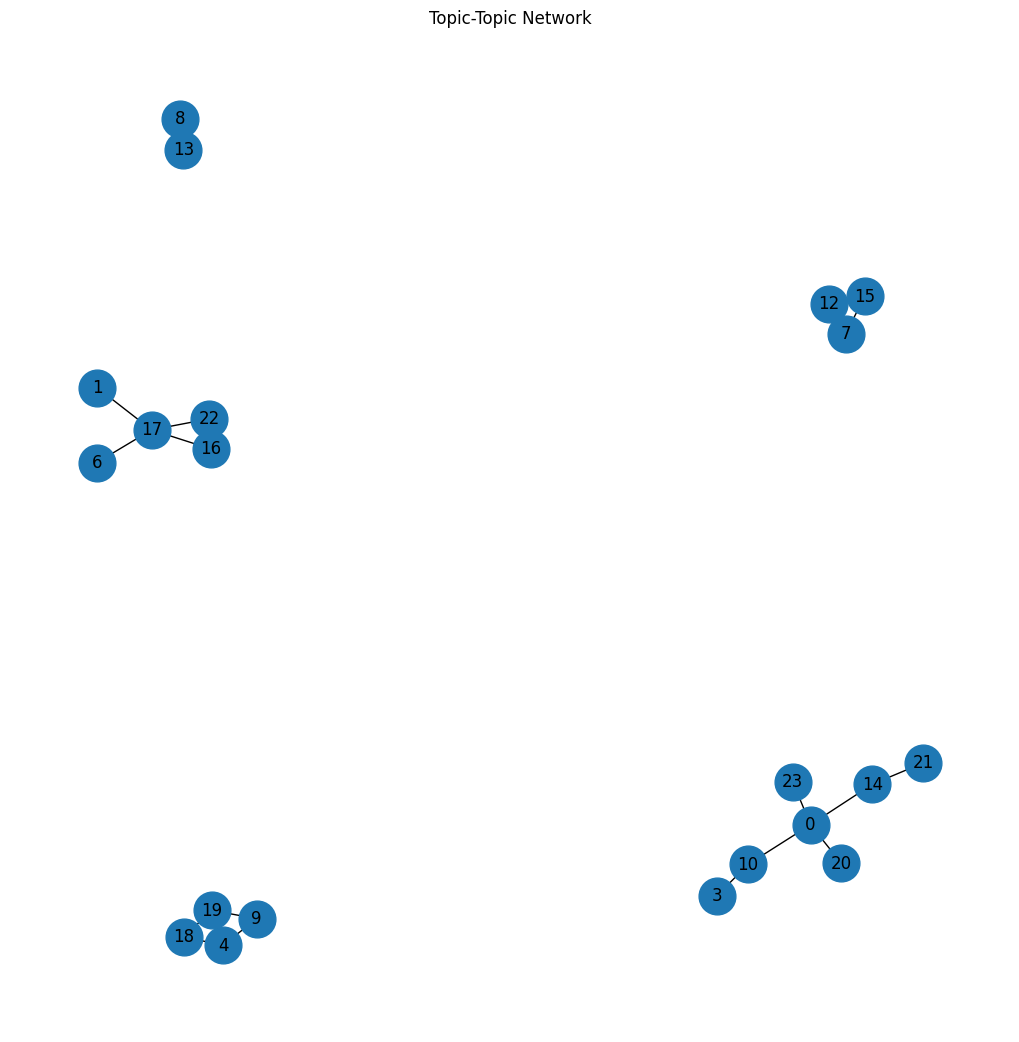

In [19]:
import numpy as np
import networkx as nx

matrix = pd.read_csv("../data/topic_modeling/topictopic.csv", header=None)
matrix = matrix.replace("-Infinity", 0).astype(float)

G = nx.Graph()

for i in range(len(matrix)):
    for j in range(len(matrix)):
        if matrix.iloc[i, j] > 0.5:  # threshold
            G.add_edge(i, j, weight=matrix.iloc[i, j])

plt.figure(figsize=(10,10))
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=700)
plt.title("Topic-Topic Network")
plt.show()

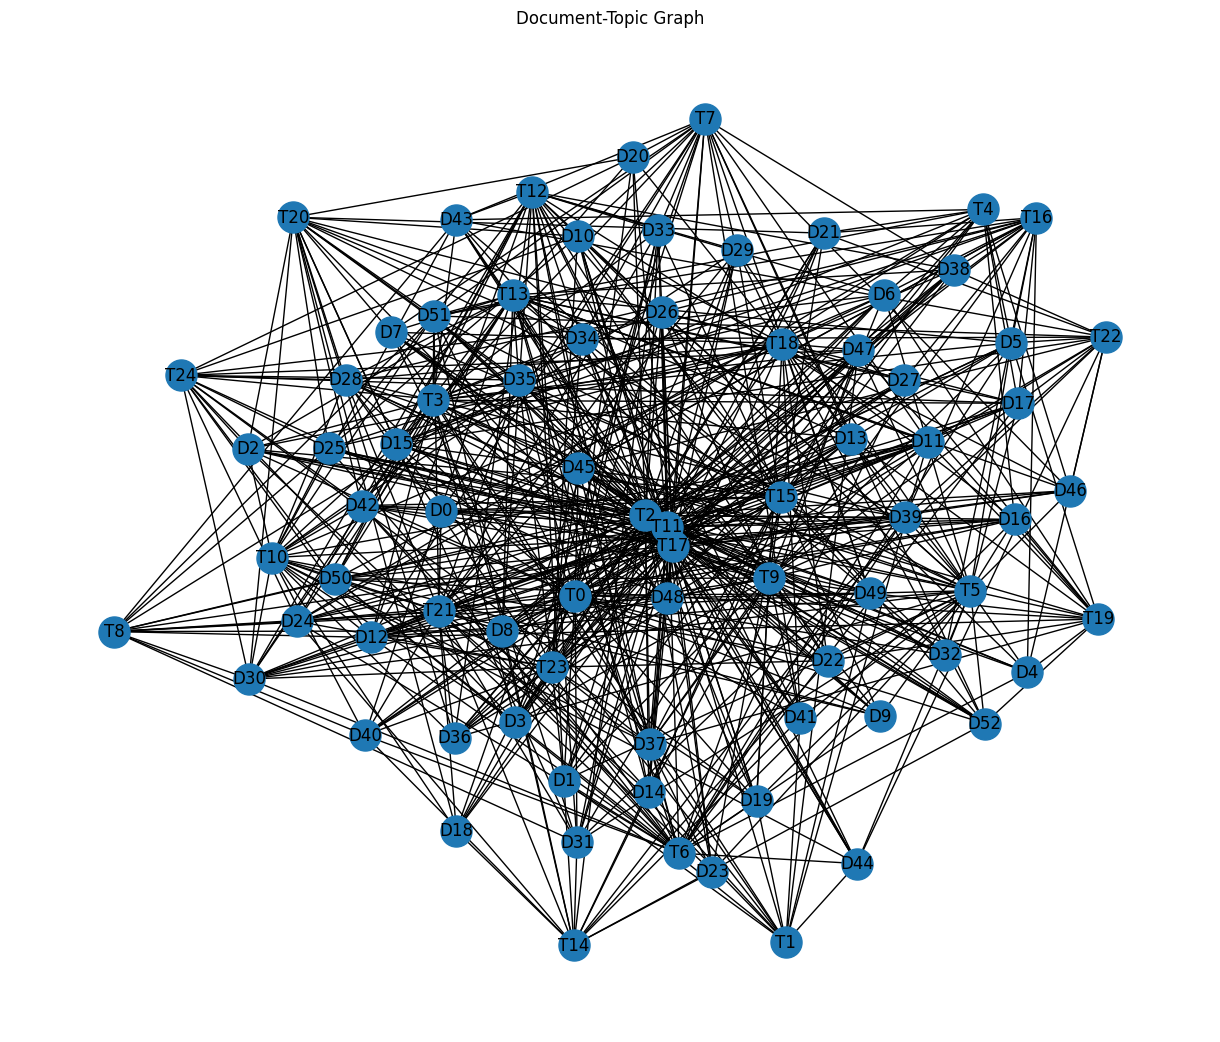

In [20]:
edges = pd.read_csv("../data/topic_modeling/gephi.csv")

G = nx.Graph()

for _, row in edges.iterrows():
    doc = f"D{row['Source']}"
    topic = f"T{row['Target']}"
    
    G.add_edge(doc, topic, weight=row["Weight"])

plt.figure(figsize=(12,10))
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=500)
plt.title("Document-Topic Graph")
plt.show()

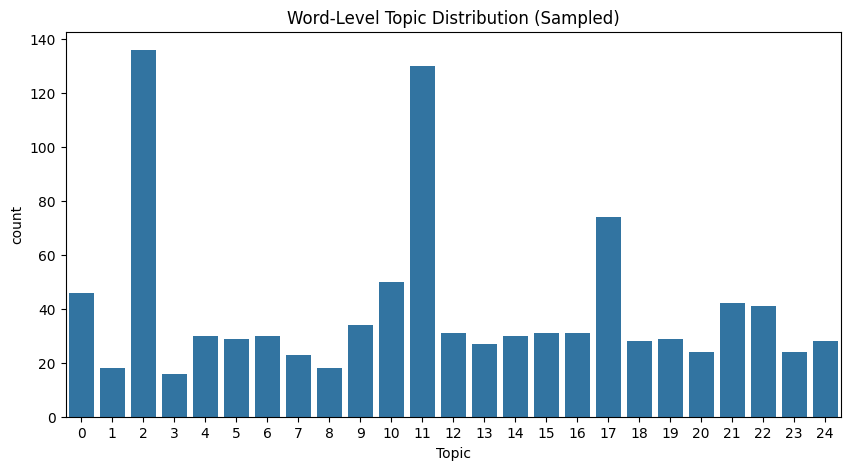

In [2]:
state = pd.read_csv("../data/topic_modeling/state.csv")

sample = state.sample(1000)

plt.figure(figsize=(10,5))
sns.countplot(x="Topic", data=sample)

plt.title("Word-Level Topic Distribution (Sampled)")
plt.show()

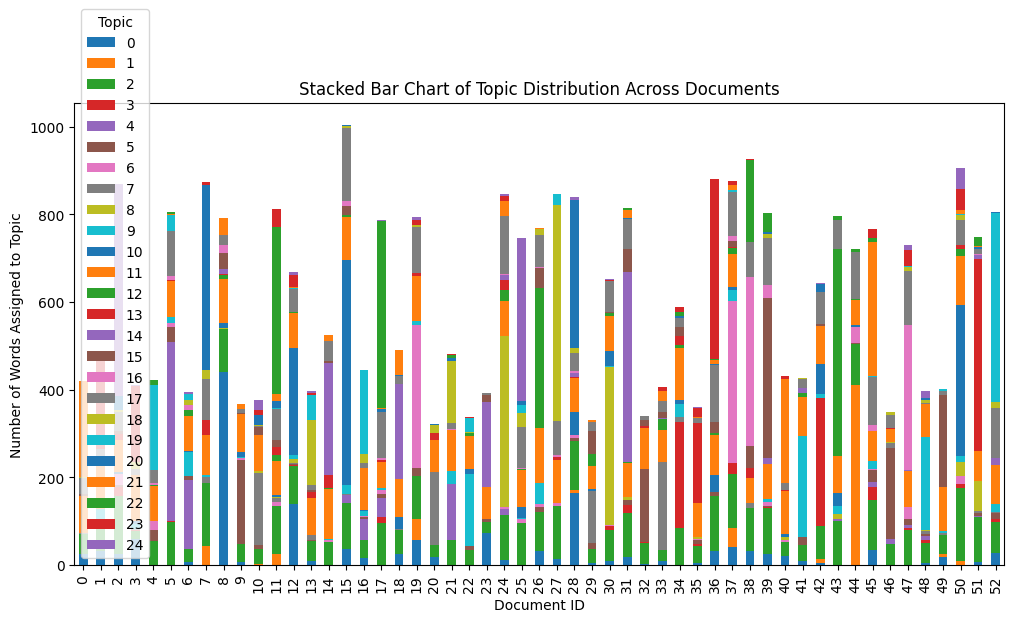

In [4]:
# state df has columns DocID, Word, Topic. i want to plot the distribution of topics across documents. 
# each document can have multiple topics, 
# i want to count the number of words assigned to each topic for each document and plot a stacked bar chart.
counts = state.groupby(["DocID", "Topic"]).size().unstack(fill_value=0)
counts.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Stacked Bar Chart of Topic Distribution Across Documents")
plt.xlabel("Document ID")
plt.ylabel("Number of Words Assigned to Topic")
plt.show()


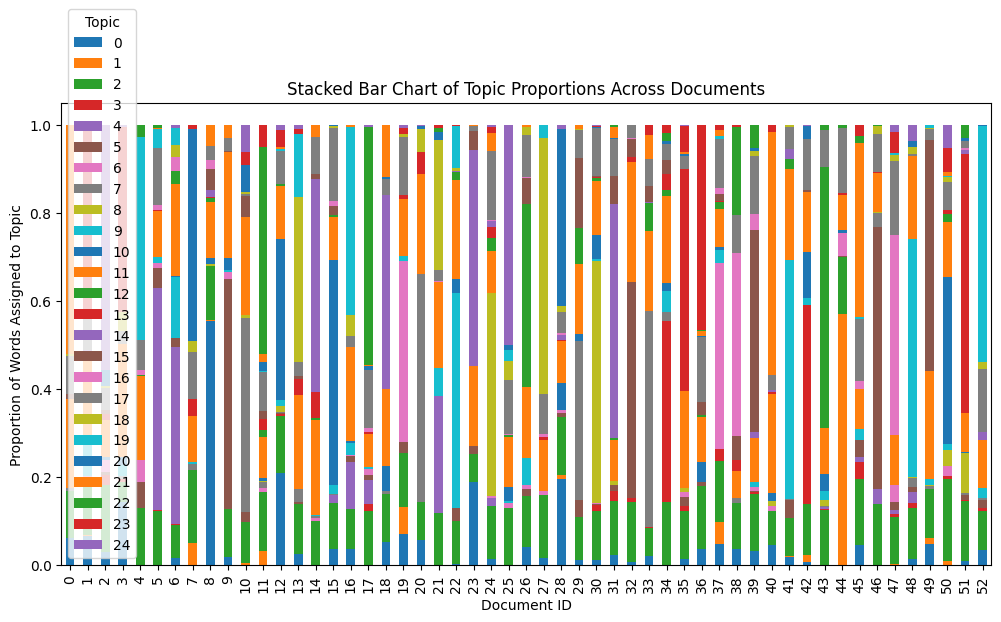

In [13]:
# make proportions from counts (divide each row by row sum)
proportions = counts.div(counts.sum(axis=1), axis=0)
proportions.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Stacked Bar Chart of Topic Proportions Across Documents")
plt.xlabel("Document ID")
plt.ylabel("Proportion of Words Assigned to Topic")
plt.show()

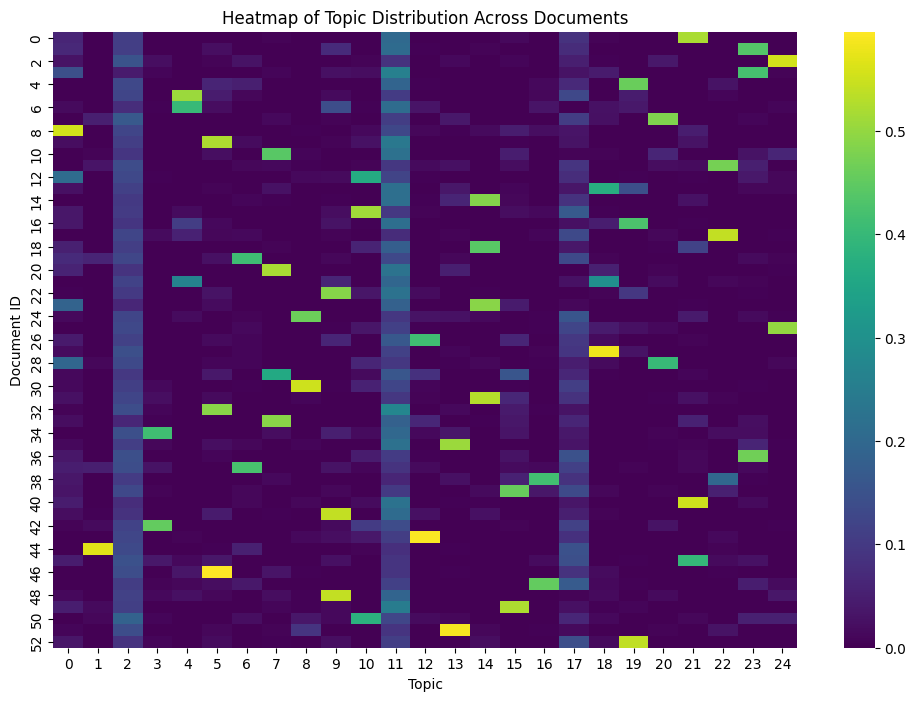

In [16]:
# i want to plot the heatmap of the topic distribution across documents.
plt.figure(figsize=(12, 8))
sns.heatmap(proportions, cmap="viridis")
plt.title("Heatmap of Topic Distribution Across Documents")
plt.xlabel("Topic")
plt.ylabel("Document ID")
plt.show()

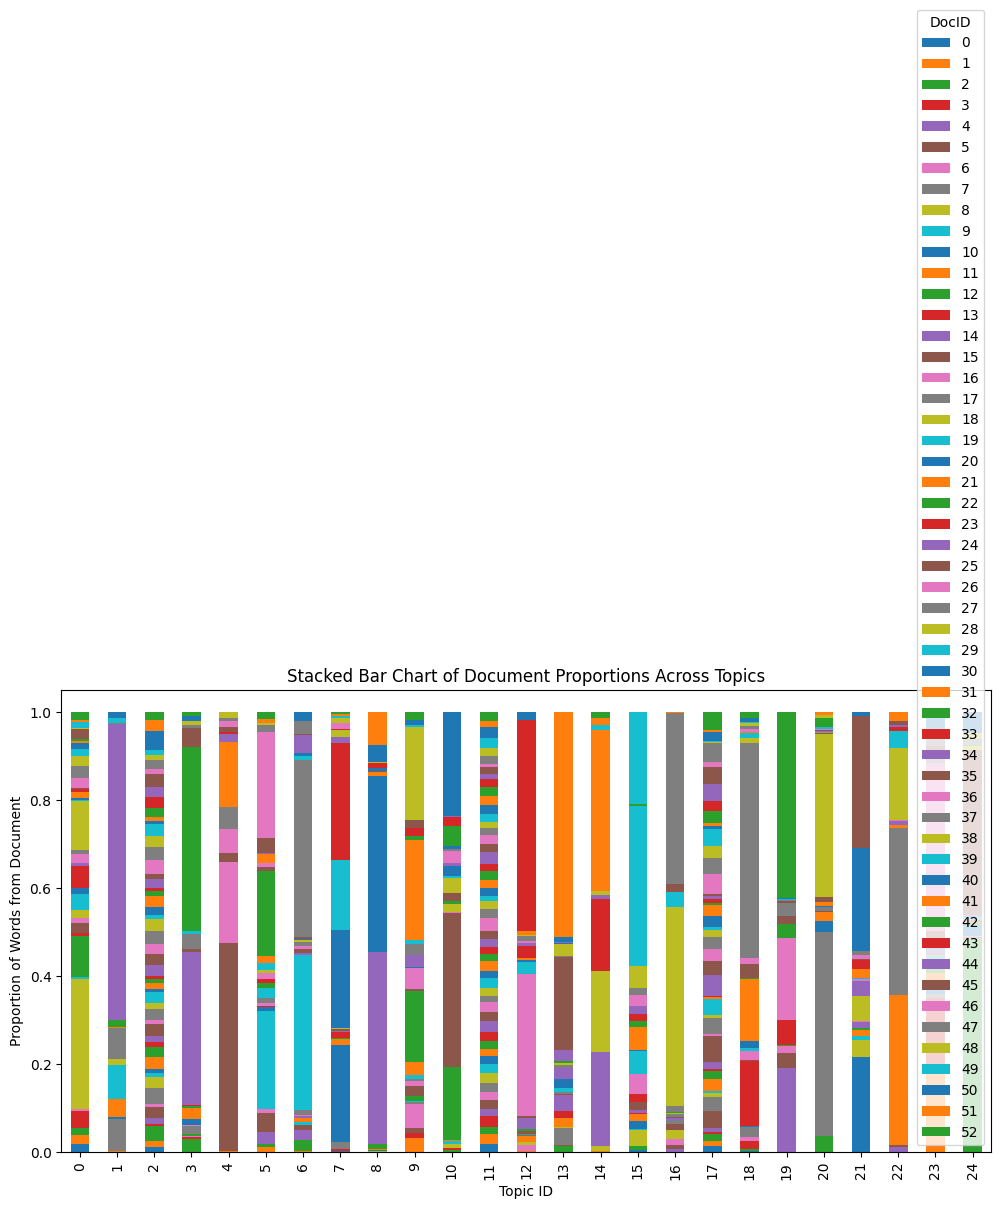

In [17]:
# make proportions from counts (divide each row by row sum)
proportions_T = counts.T.div(counts.T.sum(axis=1), axis=0)
proportions_T.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Stacked Bar Chart of Document Proportions Across Topics")
plt.xlabel("Topic ID")
plt.ylabel("Proportion of Words from Document")
plt.show()

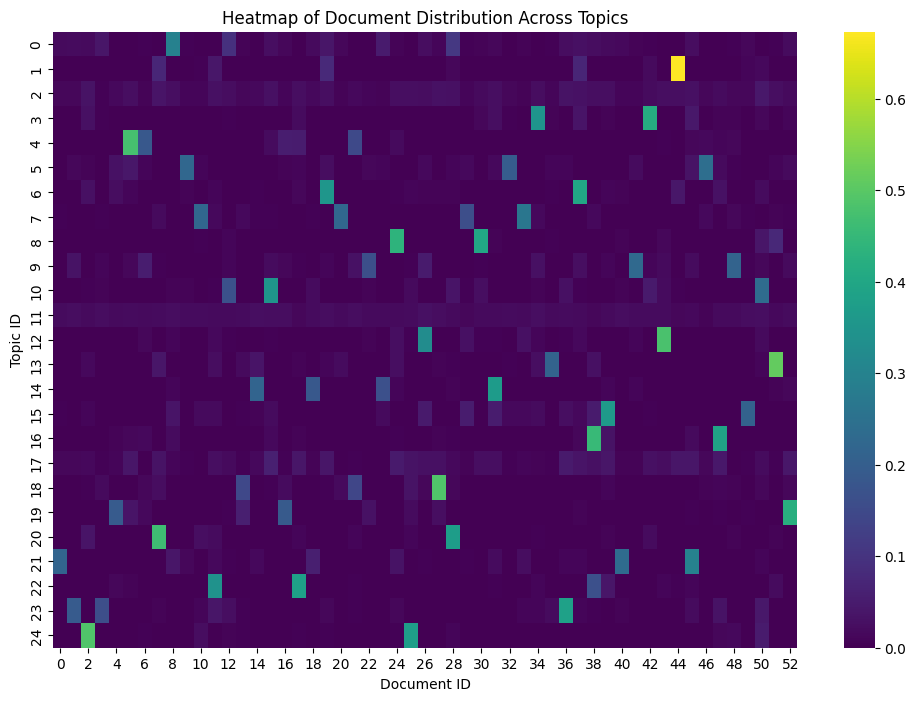

In [19]:
# i want to plot the heatmap of the topic distribution across documents.
plt.figure(figsize=(12, 8))
sns.heatmap(proportions_T, cmap="viridis")
plt.title("Heatmap of Document Distribution Across Topics")
plt.xlabel("Document ID")
plt.ylabel("Topic ID")
plt.show()

In [8]:
# print top topic for each document
state["DominantTopic"] = state.groupby("DocID")["Topic"].transform(lambda x: x.value_counts().idxmax())
dominant_topics = state[["DocID", "DominantTopic"]].drop_duplicates()
print(dominant_topics)

       DocID  DominantTopic
0          0             21
420        1             23
890        2             24
1760       3             23
2170       4             19
2592       5              4
3398       6              4
3792       7             20
4667       8              0
5459       9              5
5827      10              7
6203      11             22
7016      12             10
7684      13             18
8080      14             14
8604      15             10
9608      16             19
10054     17             22
10842     18             14
11333     19              6
12126     20              7
12448     21             18
12929     22              9
13266     23             14
13659     24              8
14505     25             24
15252     26             12
16022     27             18
16868     28             20
17708     29              7
18038     30              8
18690     31             14
19505     32              5
19846     33              7
20252     34        

In [9]:
# print top document id for each topic
topic_docs = state.groupby("Topic")["DocID"].apply(lambda x: x.value_counts().idxmax()).reset_index()
topic_docs.columns = ["Topic", "TopDocID"]
print(topic_docs)

    Topic  TopDocID
0       0         8
1       1        44
2       2        50
3       3        42
4       4         5
5       5        46
6       6        37
7       7        33
8       8        24
9       9        41
10     10        15
11     11        26
12     12        43
13     13        51
14     14        31
15     15        39
16     16        38
17     17        15
18     18        27
19     19        52
20     20         7
21     21        45
22     22        17
23     23        36
24     24         2


In [11]:
# read ministry names from data/ministry_profiles (<ministry_name>.txt file for each ministry)
ministry_names = []
import os
for filename in os.listdir("../data/ministry_profiles"):
    if filename.endswith(".txt"):
        ministry_names.append(filename[:-4])  # remove .txt extension

ministry_names

['Ministry_of_Power_MoP_',
 'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
 'Ministry_of_AYUSH_MoA_',
 'Ministry_of_Textiles_MoT_',
 'Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_',
 'Ministry_of_Law_and_Justice_MoLJ_',
 'Ministry_of_Social_Justice_and_Empowerment_MoSJE_',
 'Ministry_of_Culture',
 'Ministry_of_Heavy_Industries_MoHI_',
 'Ministry_of_Statistics_and_Programme_Implementation_MoSPI_',
 'Ministry_of_Tourism_MoT_',
 'Ministry_of_External_Affairs_MEA_',
 'Ministry_of_Food_Processing_Industries_MoFPI_',
 'Ministry_of_Skill_Development_and_Entrepreneurship_MSDE_',
 'Ministry_of_Mines_MoM_',
 'Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_',
 'Ministry_of_Women_and_Child_Development_MoWCD_',
 'Ministry_of_Home_Affairs_MHA_',
 'Ministry_of_Petroleum_and_Natural_Gas_MoPNG_',
 'Ministry_of_Electronics_and_Information_Technology_MeitY_',
 'Ministry_of_Youth_Affairs_and_Sports_MoYAS_',
 'Ministry_of_Minority_Affairs_MoMA_',
 'Ministry_of_Rural_

In [12]:
#replace topdocid in topic_docs with ministry name if it matches. then plot the distribution of ministries for each topic.
for i, row in topic_docs.iterrows():
    topic_docs.at[i, "TopDocID"] = ministry_names[row["TopDocID"]]
    
topic_docs

/tmp/ipykernel_25697/1781348923.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Ministry_of_Heavy_Industries_MoHI_' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  topic_docs.at[i, "TopDocID"] = ministry_names[row["TopDocID"]]


,Topic,TopDocID
0,0,Ministry_of_Heavy_Industries_MoHI_
1,1,Ministry_of_Information_and_Broadcasting_MIB_
2,2,Ministry_of_Agriculture_and_Farmers_Welfare_Mo...
3,3,Ministry_of_Cooperation_MoC_
4,4,Ministry_of_Law_and_Justice_MoLJ_
5,5,Ministry_of_Parliamentary_Affairs_MPA_
6,6,Ministry_of_Communications_MoC_
7,7,Ministry_of_Ports_Shipping_and_Waterways_MoPSW_
8,8,Ministry_of_Environment_Forest_and_Climate_Cha...
9,9,Ministry_of_Panchayati_Raj_MoPR_


In [30]:
# rename columns to Topic and Ministries
topic_docs.columns = ["Topic", "Ministry"]

# top ministry in each topic, save csv
topic_docs.to_csv("../data/topic_modeling/top_ministry_per_topic.csv", index=False)

In [25]:
# dominant_topics has DocID and DominantTopic
# i want to list for each topic, the documents have been assigned
topic_documents = dominant_topics.groupby("DominantTopic")["DocID"].apply(list).reset_index()
topic_documents

,DominantTopic,DocID
0,0,[8]
1,1,[44]
2,3,"[34, 42]"
3,4,"[5, 6]"
4,5,"[9, 32, 46]"
5,6,"[19, 37]"
6,7,"[10, 20, 29, 33]"
7,8,"[24, 30]"
8,9,"[22, 41, 48]"
9,10,"[12, 15, 50]"


In [26]:
# replace docids list in topic_documents with ministry_name 
for i, row in topic_documents.iterrows():
    topic_documents.at[i, "DocID"] = [ministry_names[doc_id] for doc_id in row["DocID"]]
    
topic_documents

,DominantTopic,DocID
0,0,[Ministry_of_Heavy_Industries_MoHI_]
1,1,[Ministry_of_Information_and_Broadcasting_MIB_]
2,3,[Ministry_of_Development_of_North_Eastern_Regi...
3,4,"[Ministry_of_Law_and_Justice_MoLJ_, Ministry_o..."
4,5,[Ministry_of_Statistics_and_Programme_Implemen...
5,6,[Ministry_of_Electronics_and_Information_Techn...
6,7,"[Ministry_of_Tourism_MoT_, Ministry_of_Youth_A..."
7,8,[Ministry_of_Environment_Forest_and_Climate_Ch...
8,9,"[Ministry_of_Rural_Development_MoRD_, Ministry..."
9,10,[Ministry_of_Food_Processing_Industries_MoFPI_...


In [29]:
# rename columns to Topic and Ministries
topic_documents.columns = ["Topic", "Ministries"]

# top topics for each ministry, save csv
topic_documents.to_csv("../data/topic_modeling/top_topics_per_ministry.csv", index=False)

In [24]:
import json
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [25]:
EMBED_FILE = "../data/embeddings/ministry_embeddings.json"


def load_embeddings():
    with open(EMBED_FILE, "r") as f:
        data = json.load(f)

    # convert to numpy
    for k in data:
        data[k] = np.array(data[k])

    return data

ministry_embeddings = load_embeddings()

In [26]:
import pandas as pd

topic_summary = pd.read_csv("../data/topic_modeling/keys.csv")

# Create topic text dictionary
topic_texts = {}

for _, row in topic_summary.iterrows():
    topic_id = row["Topic"]
    words = row["Words"]
    topic_texts[topic_id] = words

In [28]:
topic_texts

{0: 'sector manufacturing technology domestic limited engineering pli heavy industry public',
 1: 'film media radio mib broadcasting content certification communication cable press',
 2: 'central interventions system specific crucial management international providing nodal entities',
 3: 'cooperative eastern mdoner pacs east region moc societies limited credit',
 4: 'legal justice molj courts constitutional commission law empowerment minorities judicial',
 5: 'mop data planning implementation ministries mpa parliament niti digital monitoring',
 6: 'telecom services digital information data meity technology electronics spectrum financial',
 7: 'youth tourism ports sports budget major maritime port trains shipping',
 8: 'forest climate moefcc animal fisheries change environment conservation coastal wildlife',
 9: 'rural tribal gram scheduled panchayats mopr loans village areas rights',
 10: 'food agricultural agriculture farmers processing price consumer moafw prices crop',
 11: 'infras

In [27]:
model = SentenceTransformer("all-MiniLM-L6-v2", cache_folder="../models")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
topic_embeddings = {}
for topic_id, text in topic_texts.items():
    topic_embeddings[topic_id] = model.encode(text)

In [31]:
topic_embeddings[0].shape

(384,)

In [83]:
# save topic embeddings to json
topic_embeddings_json = {k: v.tolist() for k, v in topic_embeddings.items()}
with open("../data/embeddings/topic_embeddings.json", "w") as f:
    json.dump(topic_embeddings_json, f)

In [37]:
mapping = {}

for topic_id, t_emb in topic_embeddings.items():
    best_ministry = None
    best_score = -1
    
    for ministry, m_emb in ministry_embeddings.items():
        score = cosine_similarity([t_emb], [m_emb])[0][0]
        
        if score > best_score:
            best_score = score
            best_ministry = ministry
    
    mapping[topic_id] = (best_ministry, best_score)

for topic_id, (ministry, score) in mapping.items():
    print(f"Topic {topic_id} -> {ministry} ({score*100:.2f}%)")

Topic 0 -> Ministry_of_Heavy_Industries_MoHI_ (49.38%)
Topic 1 -> Ministry_of_Information_and_Broadcasting_MIB_ (50.35%)
Topic 2 -> Ministry_of_Minority_Affairs_MoMA_ (39.53%)
Topic 3 -> Ministry_of_Cooperation_MoC_ (44.98%)
Topic 4 -> Ministry_of_Law_and_Justice_MoLJ_ (56.97%)
Topic 5 -> Ministry_of_Parliamentary_Affairs_MPA_ (55.59%)
Topic 6 -> Ministry_of_Electronics_and_Information_Technology_MeitY_ (50.85%)
Topic 7 -> Ministry_of_Ports_Shipping_and_Waterways_MoPSW_ (40.92%)
Topic 8 -> Ministry_of_Environment_Forest_and_Climate_Change_MoEFCC_ (42.76%)
Topic 9 -> Ministry_of_Panchayati_Raj_MoPR_ (58.99%)
Topic 10 -> Ministry_of_Food_Processing_Industries_MoFPI_ (56.24%)
Topic 11 -> Ministry_of_Railways_MoR_ (25.94%)
Topic 12 -> Ministry_of_Jal_Shakti_MoJS_ (56.23%)
Topic 13 -> Ministry_of_Earth_Sciences_MoES_ (59.13%)
Topic 14 -> Ministry_of_Mines_MoM_ (47.27%)
Topic 15 -> Ministry_of_Civil_Aviation_MoCA_ (41.31%)
Topic 16 -> Ministry_of_Defence_MoD_ (52.86%)
Topic 17 -> Ministry_of

In [82]:
# save mapping to csv in format: topic_id, ministry, score
mapping_df = pd.DataFrame([(topic_id, ministry, score) for topic_id, (ministry, score) in mapping.items()], columns=["TopicID", "Ministry", "Score"])
mapping_df.to_csv("../data/topic_modeling/topic_ministry_mapping.csv", index=False)

In [39]:
# print if any ministry is mapped to multiple topics
ministry_count = {}
for topic_id, (ministry, score) in mapping.items():
    if ministry not in ministry_count:
        ministry_count[ministry] = []
    ministry_count[ministry].append(topic_id)
    
for ministry, topics in ministry_count.items():
    if len(topics) > 1:
        print(f"{ministry} is mapped to topics: {topics}")

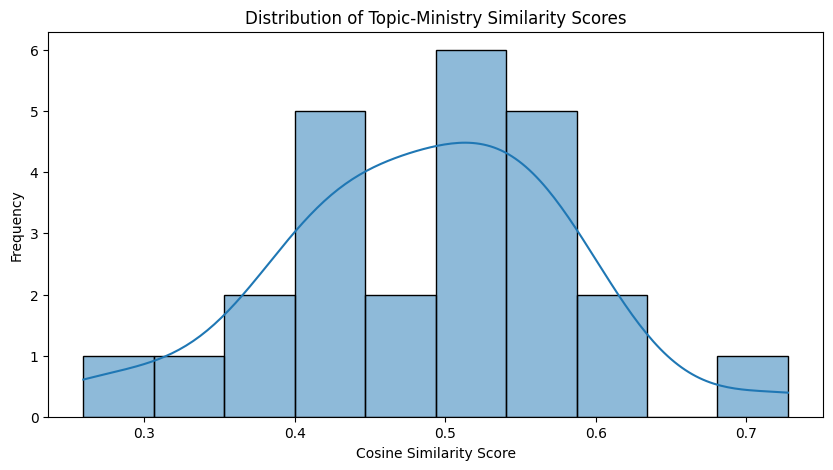

In [41]:
# plot score wise frequency distribution
scores = [score for _, score in mapping.values()]
plt.figure(figsize=(10,5))
sns.histplot(scores, bins=10, kde=True)
plt.title("Distribution of Topic-Ministry Similarity Scores")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.show()

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def bell_arrange(scores):
    scores_sorted = sorted(scores, reverse=True)
    n = len(scores_sorted)
    
    arranged = [0]*n
    center = n // 2
    
    arranged[center] = scores_sorted[0]
    
    left = center - 1
    right = center + 1
    
    i = 1
    while i < n:
        if left >= 0:
            arranged[left] = scores_sorted[i]
            i += 1
            left -= 1
        
        if i < n and right < n:
            arranged[right] = scores_sorted[i]
            i += 1
            right += 1
    
    return arranged

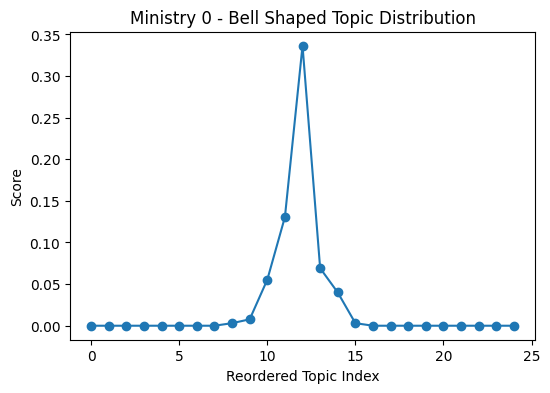

In [64]:
ministry_id = 0

scores = df.iloc[ministry_id].values
arranged_scores = bell_arrange(scores)

plt.figure(figsize=(6,4))
plt.plot(arranged_scores, marker='o')

plt.title(f"Ministry {ministry_id} - Bell Shaped Topic Distribution")
plt.xlabel("Reordered Topic Index")
plt.ylabel("Score")

plt.show()

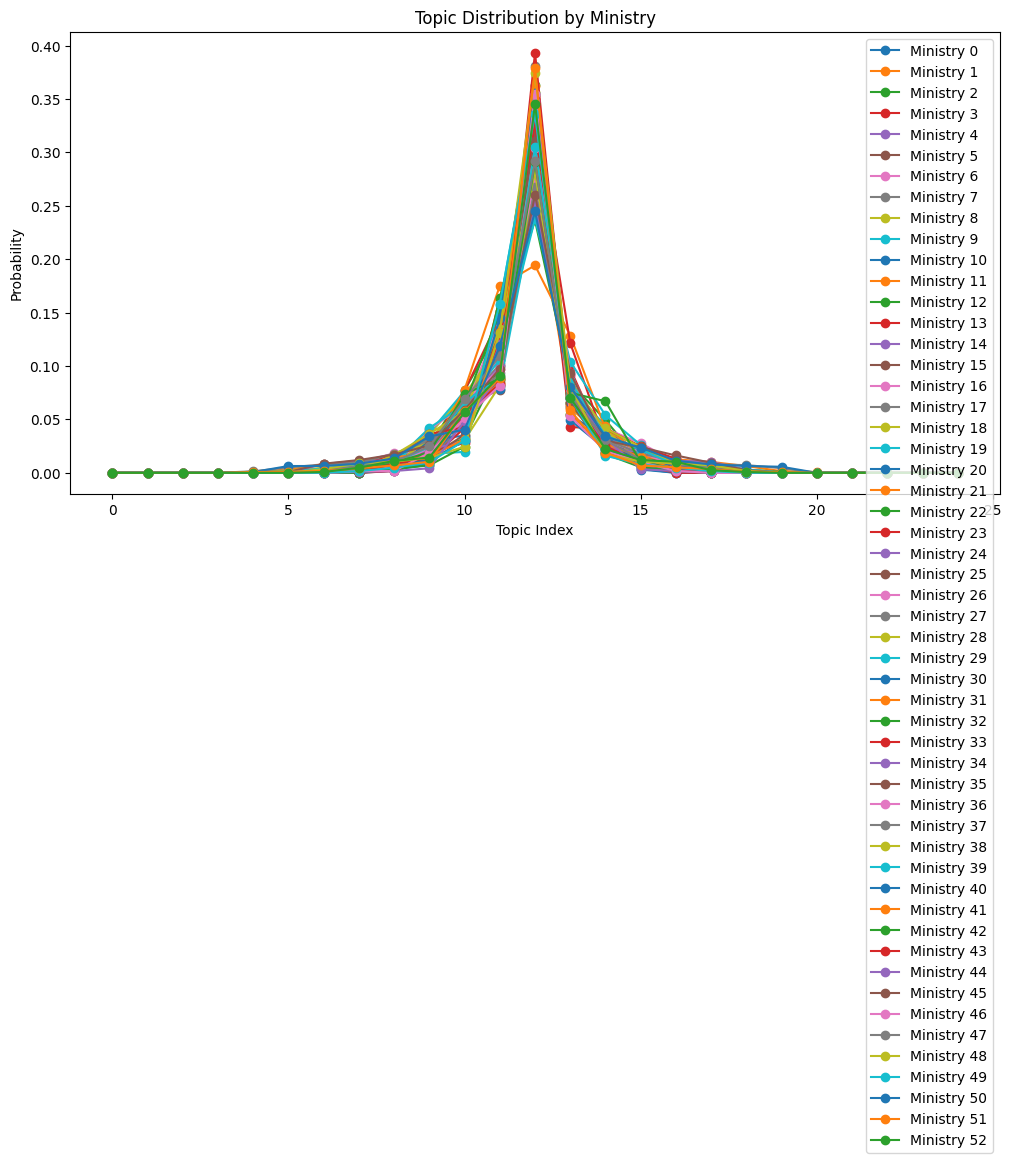

In [ ]:
plt.figure(figsize=(12,6))
for ministry_id in range(df.shape[0]):
    scores = df.iloc[ministry_id].values
    scores = bell_arrange(scores)
    plt.plot(scores, marker='o', label=f"Ministry {ministry_id}")

plt.xlabel("Topic Index")
plt.ylabel("Probability")
plt.title("Topic Distribution by Ministry")
plt.legend()
plt.show()